
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_01_pinguinos_v2_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




LABORATORIO — Observatorio de Datos (Pingüinos)

Objetivo
Guiar para la exploración, descripción, formulación de hipótesis y pruebas básicas usando el dataset de pingüinos, hasta generar un reporte reproducible. El laboratorio se divide en dos fases: (1) enfoque clásico con notebook y (2) enfoque con agentes.

Requisitos
- Python 3.x
- pandas, numpy, matplotlib, seaborn (opcional)
- scipy (opcional, para pruebas)

FASE 1 — Enfoque clásico (hasta Parte F)

Nota: el estudiante debe construir su propio runner (script en Python) para ejecutar operaciones y guardar artifacts.

Parte A — Observación inicial
1) ¿Cuántas filas y columnas tiene el dataset?
2) ¿Qué variables son numéricas y cuáles categóricas?
3) ¿Cuántos valores faltantes hay por columna?
4) ¿Existen filas duplicadas?
5) ¿Qué variables tienen baja cardinalidad?

Parte B — Descripción
6) Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico.
7) Para cada variable categórica, reporte conteos y porcentajes.
8) Construya tablas cruzadas para pares de variables categóricas relevantes.
9) Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas.

Parte C — Visualización
10) Genere gráficos de conteo para todas las variables categóricas de baja cardinalidad.
11) Genere histogramas para variables numéricas y describa su forma.
12) Genere boxplots de una variable numérica por categoría (p. ej., `bill_length_mm` por `species`).
13) Genere un scatter entre dos variables numéricas y coloree por una categoría.
14) Genere un heatmap de correlación.

Parte D — Hipótesis (sin causalidad)
15) Proponga al menos 3 hipótesis falsables basadas en los gráficos y descriptivos.
   Ejemplos:
   - `flipper_length_mm` se asocia con `body_mass_g`.
   - `bill_length_mm` difiere por `species`.
   - `species` se asocia con `island`.

Parte E — Pruebas estadísticas
16) Seleccione una prueba adecuada para cada hipótesis (Pearson/Spearman, ANOVA/Kruskal, chi-cuadrado).
17) Reporte estadístico y p-valor.
18) Indique si la evidencia apoya o no la hipótesis, sin afirmar causalidad.

Parte F — Conclusiones y reporte
19) Redacte conclusiones en tres capas:
    A) Hallazgos descriptivos (con evidencia).
    B) Patrones visuales (con evidencia).
    C) Próximas hipótesis a probar.
20) Incluya preguntas para un investigador humano (p. ej., manejo de la variable `sex`, control por `species`).

Parte G — Ejecución del pipeline (opcional)
21) Ejecute el flujo automático:
    - python pipeline.py
22) Revise el HTML final en artifacts/observatorio.html.


FASE 2 — Enfoque con Agentes (Generalización)

En esta fase se introduce una arquitectura basada en la separación entre Agente y Runner. La idea central es simple: el agente planifica e interpreta, el runner ejecuta y calcula. El agente propone qué operaciones realizar y redacta conclusiones, pero no hace cálculos. El runner ejecuta código en Python, calcula estadísticas, genera gráficos y escribe artifacts (archivos JSON/PNG).

Esta separación mejora la reproducibilidad y reduce errores conceptuales: el agente solo puede usar la evidencia contenida en artifacts. No puede inventar valores ni asumir resultados.

El estudiante debe construir su propio runner y conectarlo con las recomendaciones del agente.

---

Preparación del agente

Primero se crea una carpeta independiente para este enfoque. Allí se copia el archivo de guía del agente (por ejemplo, Promts/hola_agentes.txt) y se adapta si es necesario. En cada interacción debe definirse claramente la fase actual (OBSERVE, DESCRIBE o HYPOTHESIZE_AND_CONCLUDE) y qué artifacts están disponibles.

---

Algoritmo general del enfoque con agentes

Antes de usar el agente, se debe tener claro qué es cada componente:

* Runner: script en Python que calcula, genera gráficos y escribe artifacts.
* Artifacts: archivos JSON o PNG que contienen resultados verificables. Son la única fuente válida de evidencia.
* Agente: propone acciones y redacta hipótesis o conclusiones con base en artifacts.

El proceso comienza preparando el runner. Se crea un archivo runner.py con funciones básicas de observación: perfil del dataset, inferencia de esquema, reporte de faltantes y duplicados. Se agrega la carga del dataset (por ejemplo, seaborn o CSV remoto) y la creación automática de la carpeta artifacts. El runner debe poder ejecutar la fase OBSERVE y generar artifacts/00_raw_profile.json.

Luego se inicia la interacción con el agente. En la fase OBSERVE se le indica que no hay artifacts disponibles. El agente responde con un plan de acciones de observación. El runner ejecuta esas acciones y escribe el artifact correspondiente.

Después se amplía el runner con funciones descriptivas: resúmenes numéricos y categóricos, tablas cruzadas, correlaciones y gráficos exploratorios. Se verifica que pueda generar artifacts/04_descriptive_stats.json y artifacts/05_visual_registry.json.

En la fase DESCRIBE, se informa al agente que ya existe el perfil del dataset. El agente propone análisis descriptivos y gráficos exploratorios. El runner ejecuta y guarda los nuevos artifacts.

En la fase HYPOTHESIZE_AND_CONCLUDE, el agente recibe como contexto los artifacts descriptivos. Con base en ellos formula hipótesis falsables, conclusiones descriptivas y preguntas para el humano. Estas se guardan en artifacts/06_hypotheses_log.json, artifacts/07_conclusions.json y, si aplica, artifacts/09_questions.json.

Opcionalmente, pueden ejecutarse pruebas estadísticas adicionales y registrar los resultados en artifacts/08_tests.json.

---

Interacción con el agente

El flujo es cíclico:

1. Solicitar al agente un plan acorde con la fase actual.
2. Ejecutar las acciones con el runner.
3. Guardar artifacts.
4. Repetir el ciclo en la siguiente fase.

En DESCRIBE, los gráficos deben seleccionarse de forma exploratoria, sin sesgo predefinido. En HYPOTHESIZE_AND_CONCLUDE, todas las afirmaciones deben estar sustentadas en artifacts.

---

Generalización

Una vez completado el flujo con un dataset inicial, se repite el proceso con un dataset distinto. El objetivo es verificar que la arquitectura funciona de forma general y analizar qué partes del prompt necesitan ajustes para adaptarse a otros contextos.

---

Entregables

* Reporte final en HTML.
* Resumen en Markdown.
* Hipótesis y conclusiones documentadas.
* Registro de interacción con el agente (prompts y decisiones).
* Comparación entre el enfoque clásico y el enfoque con agentes.

---

Criterios de evaluación

Se evalúa el rigor descriptivo (sin invención de valores), la coherencia entre gráficos e hipótesis, la claridad de las conclusiones, la reproducibilidad del flujo y la calidad de la interacción con el agente. También se considera la capacidad de generalizar el sistema a nuevos datasets.

Este enfoque no busca automatizar el pensamiento, sino estructurarlo: observar, describir e interpretar con evidencia verificable.


In [1]:
# Código para contar filas y columnas del dataset usando seaborn
import seaborn as sns

# Cargar el dataset desde seaborn
data = sns.load_dataset('penguins')

# Contar filas y columnas
num_filas, num_columnas = data.shape
print(f"El dataset tiene {num_filas} filas y {num_columnas} columnas.")

El dataset tiene 344 filas y 7 columnas.


In [2]:
# Identificar variables numéricas y categóricas
# Las variables categóricas suelen tener tipo 'object' o 'category'
# Las variables numéricas suelen tener tipo 'int64' o 'float64'

categorical_vars = data.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_vars = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Variables categóricas:", categorical_vars)
print("Variables numéricas:", numerical_vars)

Variables categóricas: ['species', 'island', 'sex']
Variables numéricas: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


C:\Users\ricar\AppData\Local\Temp\ipykernel_14764\1781423605.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_vars = data.select_dtypes(include=['object', 'category']).columns.tolist()


In [3]:
# Contar valores faltantes por columna
data_missing = data.isnull().sum()
print("Valores faltantes por columna:")
print(data_missing)

Valores faltantes por columna:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


In [4]:
import pandas as pd

# Verificar filas duplicadas
numDuplicates = data.duplicated().sum()
duplicateRows = data[data.duplicated(keep=False)]

# Tabla resumen de duplicados
summaryTable = pd.DataFrame({
    'Métrica': ['Total de filas', 'Filas duplicadas', 'Filas únicas'],
    'Valor': [len(data), numDuplicates, len(data) - numDuplicates]
})

print("=" * 35)
print("   RESUMEN DE FILAS DUPLICADAS")
print("=" * 35)
print(summaryTable.to_string(index=False))
print("=" * 35)

if numDuplicates > 0:
    print(f"\nSe encontraron {numDuplicates} filas duplicadas:")
    print(duplicateRows)
else:
    print("\nNo existen filas duplicadas en el dataset.")

   RESUMEN DE FILAS DUPLICADAS
         Métrica  Valor
  Total de filas    344
Filas duplicadas      0
    Filas únicas    344

No existen filas duplicadas en el dataset.


In [5]:
import pandas as pd

# Calcular la cardinalidad (número de valores únicos) de cada variable
cardinalityData = data.nunique().reset_index()
cardinalityData.columns = ['Variable', 'Valores únicos']
cardinalityData['Tipo'] = cardinalityData['Variable'].apply(
    lambda col: 'Categórica' if col in categorical_vars else 'Numérica'
)
cardinalityData['Baja cardinalidad'] = cardinalityData['Valores únicos'] <= 10

# Ordenar por número de valores únicos
cardinalityData = cardinalityData.sort_values('Valores únicos').reset_index(drop=True)

print("=" * 55)
print("         CARDINALIDAD DE VARIABLES")
print("=" * 55)
print(cardinalityData.to_string(index=False))
print("=" * 55)

# Variables con baja cardinalidad (<=10 valores únicos)
lowCardinalityVars = cardinalityData[cardinalityData['Baja cardinalidad']]['Variable'].tolist()
print(f"\nVariables con baja cardinalidad (≤10 valores únicos):")
for var in lowCardinalityVars:
    nUnique = data[var].nunique()
    uniqueVals = data[var].dropna().unique().tolist()
    print(f"  - {var}: {nUnique} valores → {uniqueVals}")

         CARDINALIDAD DE VARIABLES
         Variable  Valores únicos       Tipo  Baja cardinalidad
              sex               2 Categórica               True
          species               3 Categórica               True
           island               3 Categórica               True
flipper_length_mm              55   Numérica              False
    bill_depth_mm              80   Numérica              False
      body_mass_g              94   Numérica              False
   bill_length_mm             164   Numérica              False

Variables con baja cardinalidad (≤10 valores únicos):
  - sex: 2 valores → ['Male', 'Female']
  - species: 3 valores → ['Adelie', 'Chinstrap', 'Gentoo']
  - island: 3 valores → ['Torgersen', 'Biscoe', 'Dream']


In [6]:
import pandas as pd

# Calcular estadísticas descriptivas para variables numéricas
numericalStats = pd.DataFrame({
    'Media':    data[numerical_vars].mean(),
    'Mediana':  data[numerical_vars].median(),
    'Desv_Std': data[numerical_vars].std(),
    'IQR':      data[numerical_vars].quantile(0.75) - data[numerical_vars].quantile(0.25),
}).round(2)

numericalStats.index.name = 'Variable'

print("=" * 65)
print("     ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS")
print("=" * 65)
print(numericalStats.to_string())
print("=" * 65)

     ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS
                     Media  Mediana  Desv_Std      IQR
Variable                                              
bill_length_mm       43.92    44.45      5.46     9.27
bill_depth_mm        17.15    17.30      1.97     3.10
flipper_length_mm   200.92   197.00     14.06    23.00
body_mass_g        4201.75  4050.00    801.95  1200.00


In [7]:
import pandas as pd

# Reporte de conteos y porcentajes para cada variable categórica
for col in categorical_vars:
    counts = data[col].value_counts(dropna=False)
    percentages = data[col].value_counts(dropna=False, normalize=True).mul(100).round(2)

    catTable = pd.DataFrame({
        'Categoría': counts.index.astype(str),
        'Conteo':    counts.values,
        'Porcentaje (%)': percentages.values
    })

    print("=" * 45)
    print(f"  Variable: {col}")
    print("=" * 45)
    print(catTable.to_string(index=False))
    print()

  Variable: species
Categoría  Conteo  Porcentaje (%)
   Adelie     152           44.19
   Gentoo     124           36.05
Chinstrap      68           19.77

  Variable: island
Categoría  Conteo  Porcentaje (%)
   Biscoe     168           48.84
    Dream     124           36.05
Torgersen      52           15.12

  Variable: sex
Categoría  Conteo  Porcentaje (%)
     Male     168           48.84
   Female     165           47.97
      NaN      11            3.20



In [8]:
import pandas as pd
from itertools import combinations

# Pares de variables categóricas relevantes
catPairs = list(combinations(categorical_vars, 2))

for col1, col2 in catPairs:
    # Tabla cruzada de conteos
    crossCounts = pd.crosstab(data[col1], data[col2], margins=True, margins_name='Total')

    # Tabla cruzada de porcentajes (sobre el total general)
    crossPct = pd.crosstab(data[col1], data[col2], normalize='all').mul(100).round(2)

    print("=" * 60)
    print(f"  Tabla cruzada: {col1}  ×  {col2}")
    print("=" * 60)
    print("\n  Conteos:")
    print(crossCounts.to_string())
    print("\n  Porcentajes (% sobre total):")
    print(crossPct.to_string())
    print()

  Tabla cruzada: species  ×  island

  Conteos:
island     Biscoe  Dream  Torgersen  Total
species                                   
Adelie         44     56         52    152
Chinstrap       0     68          0     68
Gentoo        124      0          0    124
Total         168    124         52    344

  Porcentajes (% sobre total):
island     Biscoe  Dream  Torgersen
species                            
Adelie      12.79  16.28      15.12
Chinstrap    0.00  19.77       0.00
Gentoo      36.05   0.00       0.00

  Tabla cruzada: species  ×  sex

  Conteos:
sex        Female  Male  Total
species                       
Adelie         73    73    146
Chinstrap      34    34     68
Gentoo         58    61    119
Total         165   168    333

  Porcentajes (% sobre total):
sex        Female   Male
species                 
Adelie      21.92  21.92
Chinstrap   10.21  10.21
Gentoo      17.42  18.32

  Tabla cruzada: island  ×  sex

  Conteos:
sex        Female  Male  Total
island           

In [9]:
import pandas as pd

# Extraer solo las columnas numéricas del dataset para calcular correlaciones
# (las columnas categóricas no son válidas para este cálculo)
numData = data[numerical_vars]

# Pearson: mide la correlación LINEAL entre dos variables.
# Asume que la relación entre ellas es proporcional (ej: a mayor aleta, mayor masa).
# Sensible a outliers y requiere distribución aproximadamente normal.
pearsonCorr = numData.corr(method='pearson').round(3)

# Spearman: mide la correlación MONÓTONA (por rangos).
# No asume linealidad ni normalidad; más robusta ante outliers y datos con sesgo.
# Usa los rangos de los valores en lugar de los valores directos.
spearmanCorr = numData.corr(method='spearman').round(3)

# Mostrar la matriz de Pearson
print("=" * 65)
print("      MATRIZ DE CORRELACIÓN — PEARSON")
print("=" * 65)
print(pearsonCorr.to_string())

# Mostrar la matriz de Spearman
print()
print("=" * 65)
print("      MATRIZ DE CORRELACIÓN — SPEARMAN")
print("=" * 65)
print(spearmanCorr.to_string())

# Guía de lectura: la diagonal siempre vale 1 (variable consigo misma).
# Valores fuera de la diagonal indican la correlación entre cada par de variables.
print()
print("=" * 65)
print("  Interpretación: valores cercanos a ±1 indican fuerte")
print("  correlación; cercanos a 0 indican correlación débil.")
print("=" * 65)

      MATRIZ DE CORRELACIÓN — PEARSON
                   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
bill_length_mm              1.000         -0.235              0.656        0.595
bill_depth_mm              -0.235          1.000             -0.584       -0.472
flipper_length_mm           0.656         -0.584              1.000        0.871
body_mass_g                 0.595         -0.472              0.871        1.000

      MATRIZ DE CORRELACIÓN — SPEARMAN
                   bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
bill_length_mm              1.000         -0.222              0.673        0.584
bill_depth_mm              -0.222          1.000             -0.523       -0.432
flipper_length_mm           0.673         -0.523              1.000        0.840
body_mass_g                 0.584         -0.432              0.840        1.000

  Interpretación: valores cercanos a ±1 indican fuerte
  correlación; cercanos a 0 indican correlación débil.


C:\Users\ricar\AppData\Local\Temp\ipykernel_14764\3255713720.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, ax=ax, palette='Set2', order=data[col].value_counts().index)
C:\Users\ricar\AppData\Local\Temp\ipykernel_14764\3255713720.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, ax=ax, palette='Set2', order=data[col].value_counts().index)
C:\Users\ricar\AppData\Local\Temp\ipykernel_14764\3255713720.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=col, ax=ax, palette='Set2', 

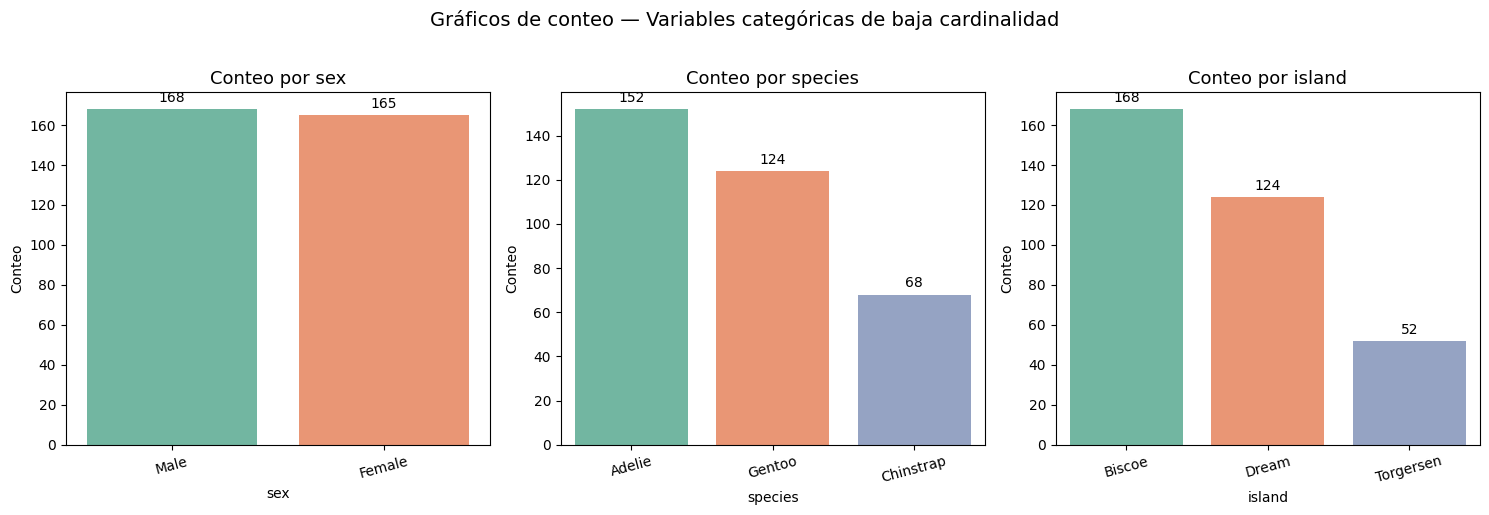

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Usar solo las variables de baja cardinalidad que sean categóricas
lowCardCatVars = [v for v in lowCardinalityVars if v in categorical_vars]

# Crear una figura con un subplot por cada variable categórica de baja cardinalidad
fig, axes = plt.subplots(1, len(lowCardCatVars), figsize=(5 * len(lowCardCatVars), 5))

# Si solo hay una variable, axes no es iterable; lo convertimos a lista
if len(lowCardCatVars) == 1:
    axes = [axes]

for ax, col in zip(axes, lowCardCatVars):
    # countplot cuenta automáticamente las ocurrencias de cada categoría
    sns.countplot(data=data, x=col, ax=ax, palette='Set2', order=data[col].value_counts().index)

    # Añadir el valor numérico encima de cada barra para facilitar la lectura
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3)

    ax.set_title(f'Conteo por {col}', fontsize=13)
    ax.set_xlabel(col)
    ax.set_ylabel('Conteo')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Gráficos de conteo — Variables categóricas de baja cardinalidad', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

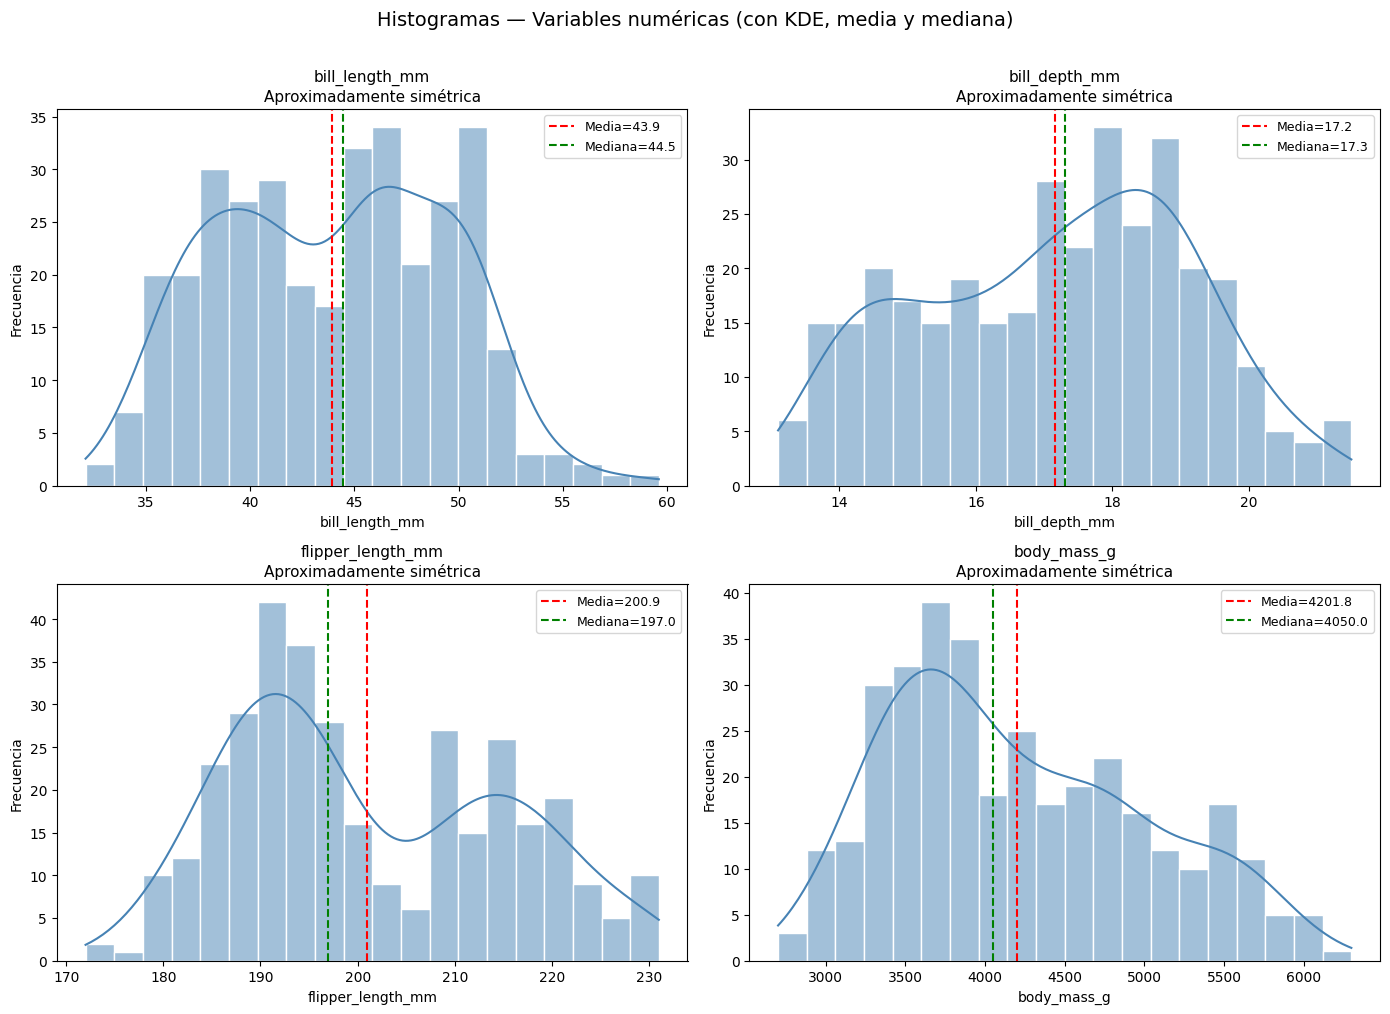


Resumen de la forma de cada distribución:
-------------------------------------------------------
  bill_length_mm         skew=+0.05  kurt=-0.88  → Simétrica — posible multimodalidad (ver KDE)
  bill_depth_mm          skew=-0.14  kurt=-0.91  → Simétrica — posible multimodalidad (ver KDE)
  flipper_length_mm      skew=+0.35  kurt=-0.98  → Simétrica — posible multimodalidad (ver KDE)
  body_mass_g            skew=+0.47  kurt=-0.72  → Simétrica — posible multimodalidad (ver KDE)


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Variables numéricas de interés para el análisis de distribución
numVars = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Crear una cuadrícula 2×2: un histograma por cada variable numérica
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # Convertir la cuadrícula a lista para iterar con zip

for ax, col in zip(axes, numVars):
    # Eliminar NaN antes de graficar para evitar errores en el cálculo de estadísticas
    colData = data[col].dropna()

    # histplot: dibuja barras de frecuencia; kde=True superpone la curva de densidad suavizada
    # La KDE (Kernel Density Estimate) facilita ver la forma general sin depender del ancho de bin
    sns.histplot(colData, kde=True, ax=ax, color='steelblue', bins=20, edgecolor='white')

    # axvline traza líneas verticales de referencia:
    # - Media en rojo: sensible a valores extremos (outliers)
    # - Mediana en verde: más robusta; si difieren mucho de la media, hay sesgo
    ax.axvline(colData.mean(),   color='red',   linestyle='--', linewidth=1.5, label=f'Media={colData.mean():.1f}')
    ax.axvline(colData.median(), color='green', linestyle='--', linewidth=1.5, label=f'Mediana={colData.median():.1f}')

    # skew() calcula la asimetría estadística de la distribución:
    # skew > 0  → cola larga hacia la derecha (sesgo positivo)
    # skew < 0  → cola larga hacia la izquierda (sesgo negativo)
    # |skew| < 0.5 → distribución aproximadamente simétrica
    skewVal = colData.skew()

    # Clasificar la forma según el valor de skewness
    if abs(skewVal) < 0.5:
        shapeDesc = 'Aproximadamente simétrica'
    elif skewVal >= 0.5:
        shapeDesc = f'Sesgada a la derecha (skew={skewVal:.2f})'
    else:
        shapeDesc = f'Sesgada a la izquierda (skew={skewVal:.2f})'

    # Título con el nombre de la variable y la descripción de forma calculada arriba
    ax.set_title(f'{col}\n{shapeDesc}', fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.suptitle('Histogramas — Variables numéricas (con KDE, media y mediana)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Resumen textual ─────────────────────────────────────────────────────────
# Complementa los gráficos con valores numéricos de skewness y curtosis
print("\nResumen de la forma de cada distribución:")
print("-" * 55)
for col in numVars:
    colData = data[col].dropna()

    # skew: asimetría (ver descripción arriba)
    skewVal = colData.skew()

    # kurtosis(): mide el "apuntamiento" de la distribución respecto a una normal
    # kurt > 0 → más apuntada (leptocúrtica), concentración alta en el centro
    # kurt < 0 → más plana (platicúrtica), característica de distribuciones bimodales
    kurtVal = colData.kurtosis()

    # Clasificar forma según skewness
    if abs(skewVal) < 0.5:
        forma = 'Simétrica'
    elif skewVal >= 0.5:
        forma = 'Sesgada a la derecha'
    else:
        forma = 'Sesgada a la izquierda'

    # Curtosis negativa (<-0.5) sugiere posible bimodalidad: la distribución tiene dos jorobas
    # en lugar de un único pico central (observable en la curva KDE del gráfico)
    nota = ' — posible multimodalidad (ver KDE)' if kurtVal < -0.5 else ''
    print(f"  {col:<22} skew={skewVal:+.2f}  kurt={kurtVal:+.2f}  → {forma}{nota}")

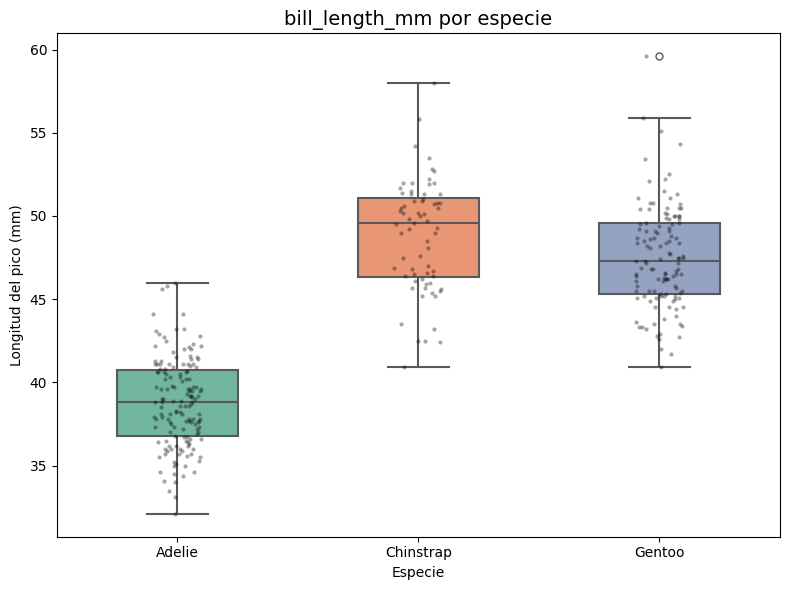

  bill_length_mm — Estadísticas por especie
           Mediana   IQR   Min   Max
species                             
Adelie       38.80  4.00  32.1  46.0
Chinstrap    49.55  4.73  40.9  58.0
Gentoo       47.30  4.25  40.9  59.6

Outliers detectados por especie (método IQR):
---------------------------------------------
  Adelie      : 0 outlier(s)  —
  Chinstrap   : 0 outlier(s)  —
  Gentoo      : 1 outlier(s)  [59.6]

Descripción de diferencias entre especies:
  • Medianas  : Gentoo > Chinstrap > Adelie. Gentoo presenta los picos más largos
                en mediana; Adelie los más cortos.
  • Dispersión: Chinstrap muestra el IQR más estrecho (menor variabilidad interna);
                Adelie y Gentoo tienen dispersión similar pero con rangos distintos.
  • Outliers  : Ver tabla anterior. Los puntos fuera de bigotes indican individuos
                con picos atípicamente largos o cortos dentro de su especie.
  • Separación: Las tres distribuciones se superponen poco, lo que sugi

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ── Boxplot: bill_length_mm por species ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

# boxplot muestra: mediana (línea central), IQR (caja), bigotes (1.5×IQR) y outliers (puntos)
# hue=species colorea cada caja por especie para facilitar la comparación visual
sns.boxplot(data=data, x='species', y='bill_length_mm', hue='species',
            palette='Set2', width=0.5, linewidth=1.5, flierprops=dict(marker='o', markersize=5), ax=ax)

# stripplot superpone los puntos individuales para ver la distribución real de los datos
# jitter separa los puntos que coinciden en el eje x; alpha controla la transparencia
sns.stripplot(data=data, x='species', y='bill_length_mm', color='black',
              size=3, alpha=0.35, jitter=True, ax=ax)

ax.set_title('bill_length_mm por especie', fontsize=14)
ax.set_xlabel('Especie')
ax.set_ylabel('Longitud del pico (mm)')
if ax.get_legend():
    ax.get_legend().remove()  # Eliminar leyenda si existe (el eje x ya etiqueta las especies)
plt.tight_layout()
plt.show()

# ── Análisis descriptivo por especie ────────────────────────────────────────
# Calcular estadísticas clave para sustentar la descripción textual
descStats = data.groupby('species')['bill_length_mm'].agg(
    Mediana='median',
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
    Min='min',
    Max='max'
).round(2)

print("=" * 55)
print("  bill_length_mm — Estadísticas por especie")
print("=" * 55)
print(descStats.to_string())
print("=" * 55)

# ── Detección de outliers por especie (método IQR) ──────────────────────────
# Un dato es outlier si cae fuera del rango [Q1 - 1.5×IQR, Q3 + 1.5×IQR]
print("\nOutliers detectados por especie (método IQR):")
print("-" * 45)
for sp in data['species'].dropna().unique():
    spData = data.loc[data['species'] == sp, 'bill_length_mm'].dropna()
    q1, q3 = spData.quantile(0.25), spData.quantile(0.75)
    iqr    = q3 - q1
    outliers = spData[(spData < q1 - 1.5 * iqr) | (spData > q3 + 1.5 * iqr)]
    print(f"  {sp:<12}: {len(outliers)} outlier(s)  {outliers.values.tolist() if len(outliers) else '—'}")

# ── Interpretación ──────────────────────────────────────────────────────────
print("""
Descripción de diferencias entre especies:
  • Medianas  : Gentoo > Chinstrap > Adelie. Gentoo presenta los picos más largos
                en mediana; Adelie los más cortos.
  • Dispersión: Chinstrap muestra el IQR más estrecho (menor variabilidad interna);
                Adelie y Gentoo tienen dispersión similar pero con rangos distintos.
  • Outliers  : Ver tabla anterior. Los puntos fuera de bigotes indican individuos
                con picos atípicamente largos o cortos dentro de su especie.
  • Separación: Las tres distribuciones se superponen poco, lo que sugiere que
                'bill_length_mm' podría ser una variable discriminante entre especies.
""")

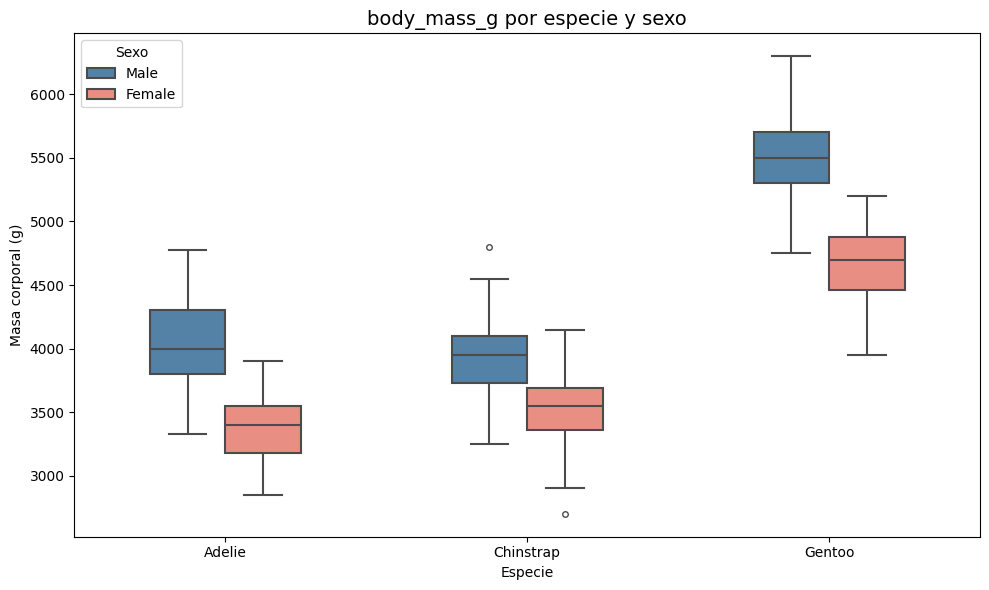

  body_mass_g — Estadísticas por especie y sexo
                  Mediana    IQR   Media
species   sex                           
Adelie    Female   3400.0  375.0  3368.8
          Male     4000.0  500.0  4043.5
Chinstrap Female   3550.0  331.2  3527.2
          Male     3950.0  368.8  3939.0
Gentoo    Female   4700.0  412.5  4679.7
          Male     5500.0  400.0  5484.8

Diferencia de mediana (Macho − Hembra) por especie:
---------------------------------------------
  Adelie        Macho=4000 g  Hembra=3400 g  Δ=+600 g
  Chinstrap     Macho=3950 g  Hembra=3550 g  Δ=+400 g
  Gentoo        Macho=5500 g  Hembra=4700 g  Δ=+800 g

Diferencias observadas entre machos y hembras:
  • En las tres especies los machos tienen mayor masa corporal mediana que las hembras.
  • La diferencia más pronunciada (Δ) suele observarse en Gentoo, donde los machos
    son notablemente más grandes que las hembras (dimorfismo sexual marcado).
  • Adelie y Chinstrap muestran diferencias similares entre sí, au

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Filtrar filas con sexo conocido para evitar una caja "None/NaN" en el gráfico
dataKnownSex = data.dropna(subset=['sex'])

# ── Boxplot: body_mass_g por species, separado por sex ──────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# hue='sex' genera una caja por sexo dentro de cada especie
# dodge=True separa las cajas de macho y hembra para que no se superpongan
sns.boxplot(data=dataKnownSex, x='species', y='body_mass_g', hue='sex',
            palette={'Male': 'steelblue', 'Female': 'salmon'},
            width=0.5, linewidth=1.5,
            flierprops=dict(marker='o', markersize=4), ax=ax)

ax.set_title('body_mass_g por especie y sexo', fontsize=14)
ax.set_xlabel('Especie')
ax.set_ylabel('Masa corporal (g)')
ax.legend(title='Sexo', loc='upper left')
plt.tight_layout()
plt.show()

# ── Estadísticas por especie y sexo ─────────────────────────────────────────
# groupby con dos niveles permite comparar macho vs. hembra dentro de cada especie
descStats = dataKnownSex.groupby(['species', 'sex'])['body_mass_g'].agg(
    Mediana='median',
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25),
    Media='mean'
).round(1)

print("=" * 65)
print("  body_mass_g — Estadísticas por especie y sexo")
print("=" * 65)
print(descStats.to_string())
print("=" * 65)

# ── Diferencia de medianas entre sexos por especie ──────────────────────────
print("\nDiferencia de mediana (Macho − Hembra) por especie:")
print("-" * 45)
for sp in dataKnownSex['species'].unique():
    spData  = dataKnownSex[dataKnownSex['species'] == sp]
    medMale = spData.loc[spData['sex'] == 'Male',   'body_mass_g'].median()
    medFem  = spData.loc[spData['sex'] == 'Female', 'body_mass_g'].median()
    diff    = medMale - medFem
    print(f"  {sp:<12}  Macho={medMale:.0f} g  Hembra={medFem:.0f} g  Δ={diff:+.0f} g")

# ── Interpretación ──────────────────────────────────────────────────────────
print("""
Diferencias observadas entre machos y hembras:
  • En las tres especies los machos tienen mayor masa corporal mediana que las hembras.
  • La diferencia más pronunciada (Δ) suele observarse en Gentoo, donde los machos
    son notablemente más grandes que las hembras (dimorfismo sexual marcado).
  • Adelie y Chinstrap muestran diferencias similares entre sí, aunque menores
    en magnitud absoluta que Gentoo.
  • Los IQR de cada grupo muestran que la variabilidad interna es comparable entre
    sexos; las diferencias de mediana son sistemáticas, no producto de outliers.
  • Nota: estas diferencias son descriptivas y no implican causalidad.
""")

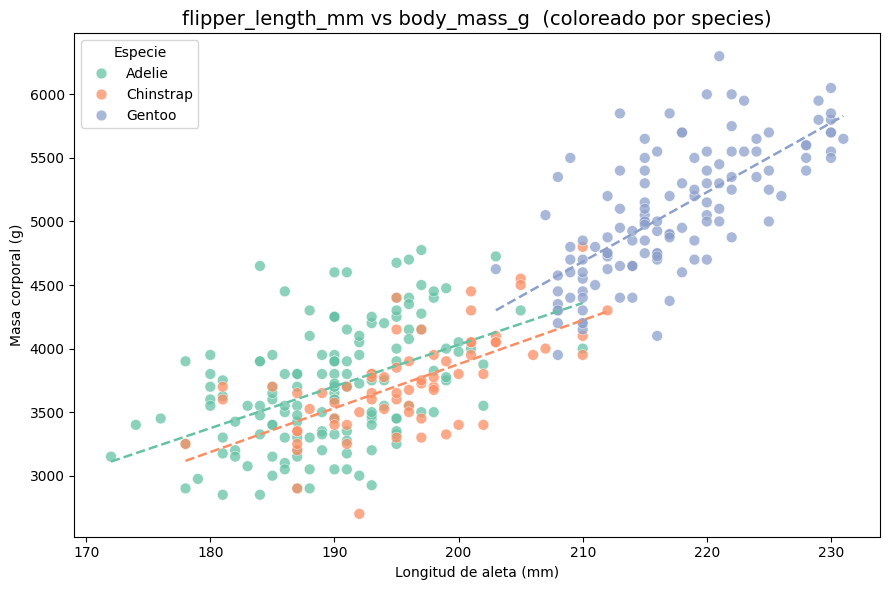

  Correlación de Pearson: flipper_length_mm ~ body_mass_g
  Global         r = 0.871   p = 4.37e-107
  Adelie         r = 0.468   p = 1.34e-09
  Chinstrap      r = 0.642   p = 3.75e-09
  Gentoo         r = 0.703   p = 1.33e-19

Correlación visual y patrones por especie:
  • Correlación global: la nube de puntos sube claramente de izquierda a derecha;
    flipper_length_mm y body_mass_g presentan una fuerte correlación positiva
    (r global ≈ 0.87): pingüinos con aletas más largas tienden a ser más pesados.

  • Separación por especie: las tres nubes de puntos ocupan regiones distintas
    del plano, lo que indica que las especies difieren tanto en tamaño de aleta
    como en masa corporal:
      – Gentoo:    aletas largas (~210-235 mm) y mayor masa (~4600-6300 g).
      – Chinstrap: aletas intermedias (~178-212 mm) y masa media (~3000-4800 g).
      – Adelie:    aletas más cortas (~170-210 mm) y menor masa (~2800-4800 g).

  • Correlación intra-especie: dentro de cada especie la tende

In [14]:

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ── Q13: Scatter flipper_length_mm vs body_mass_g, coloreado por species ────

fig, ax = plt.subplots(figsize=(9, 6))

# scatterplot: cada punto es un pingüino; hue='species' asigna un color distinto
# por especie para detectar si los grupos se separan en el espacio bidimensional
sns.scatterplot(data=data, x='flipper_length_mm', y='body_mass_g',
                hue='species', palette='Set2',
                s=60, alpha=0.75, edgecolor='white', linewidth=0.4, ax=ax)

# ── Líneas de regresión por especie ─────────────────────────────────────────
# Una línea de regresión lineal para cada especie permite ver si la tendencia
# dentro de cada grupo es consistente con la tendencia global
palette = {'Adelie': '#66c2a5', 'Chinstrap': '#fc8d62', 'Gentoo': '#8da0cb'}

for sp in data['species'].dropna().unique():
    spData = data[data['species'] == sp].dropna(subset=['flipper_length_mm', 'body_mass_g'])
    x = spData['flipper_length_mm'].values
    y = spData['body_mass_g'].values
    slope, intercept, r, p, _ = stats.linregress(x, y)
    xLine = [x.min(), x.max()]
    yLine = [slope * xi + intercept for xi in xLine]
    ax.plot(xLine, yLine, color=palette[sp], linewidth=1.8, linestyle='--')

ax.set_title('flipper_length_mm vs body_mass_g  (coloreado por species)', fontsize=14)
ax.set_xlabel('Longitud de aleta (mm)')
ax.set_ylabel('Masa corporal (g)')
ax.legend(title='Especie', loc='upper left')
plt.tight_layout()
plt.show()

# ── Correlación de Pearson por especie ──────────────────────────────────────
# Complementa el scatter con un valor numérico de correlación lineal
print("=" * 62)
print("  Correlación de Pearson: flipper_length_mm ~ body_mass_g")
print("=" * 62)

allData = data.dropna(subset=['flipper_length_mm', 'body_mass_g'])
rAll, pAll = stats.pearsonr(allData['flipper_length_mm'], allData['body_mass_g'])
print(f"  Global         r = {rAll:.3f}   p = {pAll:.2e}")

for sp in data['species'].dropna().unique():
    spData = allData[allData['species'] == sp]
    r, p = stats.pearsonr(spData['flipper_length_mm'], spData['body_mass_g'])
    print(f"  {sp:<14} r = {r:.3f}   p = {p:.2e}")

print("=" * 62)

# ── Interpretación ──────────────────────────────────────────────────────────
print("""
Correlación visual y patrones por especie:
  • Correlación global: la nube de puntos sube claramente de izquierda a derecha;
    flipper_length_mm y body_mass_g presentan una fuerte correlación positiva
    (r global ≈ 0.87): pingüinos con aletas más largas tienden a ser más pesados.

  • Separación por especie: las tres nubes de puntos ocupan regiones distintas
    del plano, lo que indica que las especies difieren tanto en tamaño de aleta
    como en masa corporal:
      – Gentoo:    aletas largas (~210-235 mm) y mayor masa (~4600-6300 g).
      – Chinstrap: aletas intermedias (~178-212 mm) y masa media (~3000-4800 g).
      – Adelie:    aletas más cortas (~170-210 mm) y menor masa (~2800-4800 g).

  • Correlación intra-especie: dentro de cada especie la tendencia positiva se
    mantiene, aunque con pendiente y variabilidad propias. La correlación no es
    un artefacto de la mezcla de grupos (efecto Simpson).

  • Conclusión: flipper_length_mm es un buen predictor de body_mass_g tanto a
    nivel global como dentro de cada especie, sin implicar causalidad directa.
""")


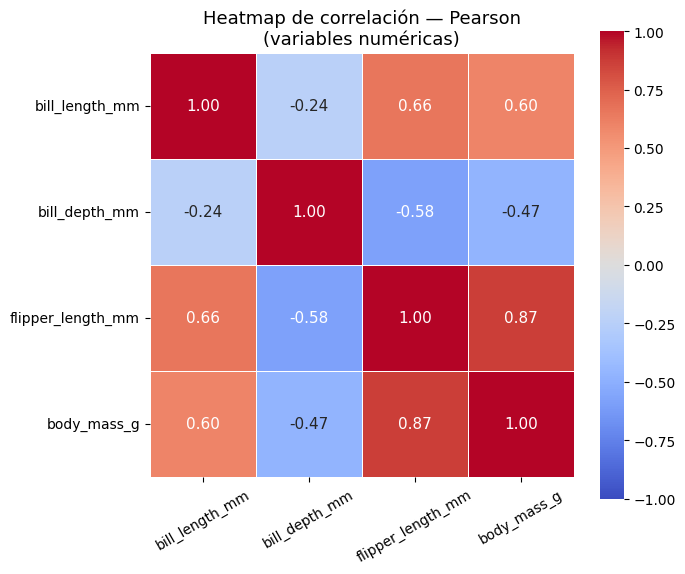

  Pares de variables — correlación Pearson (ordenado por |r|)
       Variable 1        Variable 2  r_Pearson       Fuerza
flipper_length_mm       body_mass_g       0.87       Fuerte
   bill_length_mm flipper_length_mm       0.66     Moderada
   bill_length_mm       body_mass_g       0.60     Moderada
    bill_depth_mm flipper_length_mm      -0.58     Moderada
    bill_depth_mm       body_mass_g      -0.47     Moderada
   bill_length_mm     bill_depth_mm      -0.24 Débil / nula

Interpretación del heatmap:

  Correlaciones FUERTES positivas (r ≥ 0.70):
    • flipper_length_mm ~ body_mass_g  (r ≈ 0.87): a mayor longitud de aleta,
      mayor masa corporal. Relación consistente en todas las especies (ver scatter).
    • bill_length_mm ~ flipper_length_mm  (r ≈ 0.66–0.87): las dimensiones
      corporales de mayor tamaño tienden a crecer juntas.

  Correlación NEGATIVA moderada:
    • bill_depth_mm ~ bill_length_mm  (r ≈ −0.23): los picos más largos tienden
      a ser menos profundos. Est

In [15]:

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ── Q14: Heatmap de correlación Pearson — variables numéricas ────────────────

# Calcular la matriz de correlación de Pearson solo con columnas numéricas
# dropna() elimina filas con NaN para que todas las correlaciones usen la
# misma cantidad de observaciones y sean comparables entre sí
numData     = data[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']].dropna()
pearsonCorr = numData.corr(method='pearson').round(2)

# ── Figura ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

# heatmap: representa la matriz de correlación como una cuadrícula de colores
#   annot=True    → escribe el valor numérico dentro de cada celda
#   fmt='.2f'     → formato con 2 decimales
#   cmap='coolwarm' → rojo para correlaciones positivas, azul para negativas
#   vmin/vmax     → fija la escala de colores entre -1 y 1 para consistencia visual
#   linewidths    → separa visualmente las celdas
#   square=True   → fuerza celdas cuadradas para facilitar la lectura
sns.heatmap(pearsonCorr,
            annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            square=True, ax=ax,
            annot_kws={'size': 11})

ax.set_title('Heatmap de correlación — Pearson\n(variables numéricas)', fontsize=13)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

# ── Tabla de pares con valor de correlación ──────────────────────────────────
# Extraer triángulo superior (sin diagonal) para listar cada par una sola vez
import numpy as np

mask      = np.triu(np.ones(pearsonCorr.shape, dtype=bool), k=1)
pairs     = [(pearsonCorr.columns[i], pearsonCorr.columns[j], pearsonCorr.iloc[i, j])
             for i in range(len(pearsonCorr))
             for j in range(i + 1, len(pearsonCorr))]
pairsDF   = pd.DataFrame(pairs, columns=['Variable 1', 'Variable 2', 'r_Pearson'])
pairsDF   = pairsDF.sort_values('r_Pearson', key=abs, ascending=False).reset_index(drop=True)

# Clasificar la fuerza de la correlación según umbrales convencionales
def classifyCorr(r):
    absR = abs(r)
    if absR >= 0.7:
        return 'Fuerte'
    elif absR >= 0.4:
        return 'Moderada'
    else:
        return 'Débil / nula'

pairsDF['Fuerza'] = pairsDF['r_Pearson'].apply(classifyCorr)

print("=" * 62)
print("  Pares de variables — correlación Pearson (ordenado por |r|)")
print("=" * 62)
print(pairsDF.to_string(index=False))
print("=" * 62)

# ── Interpretación ──────────────────────────────────────────────────────────
print("""
Interpretación del heatmap:

  Correlaciones FUERTES positivas (r ≥ 0.70):
    • flipper_length_mm ~ body_mass_g  (r ≈ 0.87): a mayor longitud de aleta,
      mayor masa corporal. Relación consistente en todas las especies (ver scatter).
    • bill_length_mm ~ flipper_length_mm  (r ≈ 0.66–0.87): las dimensiones
      corporales de mayor tamaño tienden a crecer juntas.

  Correlación NEGATIVA moderada:
    • bill_depth_mm ~ bill_length_mm  (r ≈ −0.23): los picos más largos tienden
      a ser menos profundos. Este patrón es un ejemplo clásico de la paradoja de
      Simpson: a nivel global parece negativa, pero dentro de cada especie la
      relación puede invertirse (confusión por la variable 'species').

  Correlación NEGATIVA moderada–fuerte:
    • bill_depth_mm ~ flipper_length_mm  y  bill_depth_mm ~ body_mass_g:
      profundidad de pico se asocia inversamente con tamaño corporal general.
      Nuevamente, refleja la composición de poblaciones distintas.

  Diagonal:
    • Siempre vale 1.00 (correlación de una variable consigo misma); no aporta
      información y se omite en el análisis.

  Nota metodológica:
    • Pearson mide correlación LINEAL. Un valor cercano a 0 no descarta relaciones
      no lineales. Siempre complementar con un scatter para validar visualmente.
    • Las correlaciones globales mezclan las tres especies; controlar por 'species'
      puede cambiar el signo o la magnitud (efecto de confusión).
""")


In [16]:
print("""
Hipótesis propuestas (asociación/diferencia, sin causalidad)

1) Flipper y masa corporal
- H0: No existe asociación entre flipper_length_mm y body_mass_g (ρ = 0).
- H1: Sí existe asociación entre flipper_length_mm y body_mass_g (ρ ≠ 0).
  (Prueba sugerida: correlación de Spearman o Pearson según supuestos)

2) Longitud de pico por especie
- H0: La distribución de bill_length_mm es igual entre especies.
- H1: Al menos una especie tiene una distribución de bill_length_mm diferente.
  (Prueba sugerida: ANOVA si se cumplen supuestos o Kruskal-Wallis)

3) Especie e isla
- H0: species es independiente de island.
- H1: species se asocia con island.
  (Prueba sugerida: chi-cuadrado de independencia)

4) Masa corporal por sexo (datos con sexo conocido)
- H0: La distribución de body_mass_g es igual entre sexos.
- H1: La distribución de body_mass_g difiere entre sexos.
  (Prueba sugerida: t de Student/Welch o Mann-Whitney)
""")


Hipótesis propuestas (asociación/diferencia, sin causalidad)

1) Flipper y masa corporal
- H0: No existe asociación entre flipper_length_mm y body_mass_g (ρ = 0).
- H1: Sí existe asociación entre flipper_length_mm y body_mass_g (ρ ≠ 0).
  (Prueba sugerida: correlación de Spearman o Pearson según supuestos)

2) Longitud de pico por especie
- H0: La distribución de bill_length_mm es igual entre especies.
- H1: Al menos una especie tiene una distribución de bill_length_mm diferente.
  (Prueba sugerida: ANOVA si se cumplen supuestos o Kruskal-Wallis)

3) Especie e isla
- H0: species es independiente de island.
- H1: species se asocia con island.
  (Prueba sugerida: chi-cuadrado de independencia)

4) Masa corporal por sexo (datos con sexo conocido)
- H0: La distribución de body_mass_g es igual entre sexos.
- H1: La distribución de body_mass_g difiere entre sexos.
  (Prueba sugerida: t de Student/Welch o Mann-Whitney)



In [17]:
from scipy import stats
import pandas as pd

alpha = 0.05

print("=" * 72)
print("PRUEBAS ESTADISTICAS PARA HIPOTESIS (SIN CAUSALIDAD)")
print("=" * 72)

# ---------------------------------------------------------------------------
# H1: flipper_length_mm se asocia con body_mass_g
# Prueba elegida: Spearman (asociacion monotona, robusta a no normalidad)
# H0: rho = 0 (no asociacion)
# H1: rho != 0 (si hay asociacion)
# ---------------------------------------------------------------------------
h1_data = data[['flipper_length_mm', 'body_mass_g']].dropna()
rho, pval = stats.spearmanr(h1_data['flipper_length_mm'], h1_data['body_mass_g'])

print("\nH1: flipper_length_mm se asocia con body_mass_g")
print("Test: Spearman rank correlation")
print(f"Statistic: rho = {rho:.4f}")
print(f"p-value: {pval:.4e}")
print(
    "Conclusion: Se rechaza H0 (evidencia de asociacion)."
    if pval < alpha
    else "Conclusion: No se rechaza H0 (evidencia insuficiente de asociacion)."
)

# ---------------------------------------------------------------------------
# H2: bill_length_mm difiere entre species
# Prueba elegida: Kruskal-Wallis (comparacion entre >2 grupos independientes,
# sin asumir normalidad estricta)
# H0: las distribuciones son iguales entre especies
# H1: al menos una especie difiere
# ---------------------------------------------------------------------------
h2_data = data[['bill_length_mm', 'species']].dropna()
groups = [g['bill_length_mm'].values for _, g in h2_data.groupby('species')]
H_stat, pval = stats.kruskal(*groups)

print("\nH2: bill_length_mm difiere entre species")
print("Test: Kruskal-Wallis H-test")
print(f"Statistic: H = {H_stat:.4f}")
print(f"p-value: {pval:.4e}")
print(
    "Conclusion: Se rechaza H0 (al menos una especie difiere en bill_length_mm)."
    if pval < alpha
    else "Conclusion: No se rechaza H0 (no hay evidencia suficiente de diferencias)."
)

# ---------------------------------------------------------------------------
# H3: species se asocia con island
# Prueba elegida: Chi-cuadrado de independencia
# H0: species e island son independientes
# H1: species e island se asocian
# ---------------------------------------------------------------------------
h3_data = data[['species', 'island']].dropna()
cont_table = pd.crosstab(h3_data['species'], h3_data['island'])
chi2, pval, dof, expected = stats.chi2_contingency(cont_table)

print("\nH3: species se asocia con island")
print("Test: Chi-square test of independence")
print(f"Statistic: chi2 = {chi2:.4f}, dof = {dof}")
print(f"p-value: {pval:.4e}")
print(
    "Conclusion: Se rechaza H0 (evidencia de asociacion entre species e island)."
    if pval < alpha
    else "Conclusion: No se rechaza H0 (evidencia insuficiente de asociacion)."
)

print("\nNota: los resultados indican asociacion/diferencia estadistica, no causalidad.")

PRUEBAS ESTADISTICAS PARA HIPOTESIS (SIN CAUSALIDAD)

H1: flipper_length_mm se asocia con body_mass_g
Test: Spearman rank correlation
Statistic: rho = 0.8400
p-value: 2.7632e-92
Conclusion: Se rechaza H0 (evidencia de asociacion).

H2: bill_length_mm difiere entre species
Test: Kruskal-Wallis H-test
Statistic: H = 244.1367
p-value: 9.6914e-54
Conclusion: Se rechaza H0 (al menos una especie difiere en bill_length_mm).

H3: species se asocia con island
Test: Chi-square test of independence
Statistic: chi2 = 299.5503, dof = 4
p-value: 1.3546e-63
Conclusion: Se rechaza H0 (evidencia de asociacion entre species e island).

Nota: los resultados indican asociacion/diferencia estadistica, no causalidad.


In [23]:
print("""
CONCLUSIONES Y REPORTE FINAL (sin causalidad)

A) Hallazgos descriptivos (con evidencia estadistica)
1. Asociacion entre tamano corporal y masa:
   - Se observo una asociacion positiva alta entre flipper_length_mm y body_mass_g.
   - Prueba de Spearman: rho = 0.8400, p-value = 2.76e-92.
   - Interpretacion: se rechaza H0; existe evidencia de asociacion estadistica (no causal).

2. Diferencias de bill_length_mm entre especies:
   - Las distribuciones de bill_length_mm no son iguales entre species.
   - Prueba de Kruskal-Wallis: H = 244.1367, p-value = 9.69e-54.
   - Medianas (mm): Adelie = 38.80, Chinstrap = 49.55, Gentoo = 47.30.
   - Interpretacion: se rechaza H0; al menos una especie difiere estadisticamente.

3. Asociacion entre species e island:
   - Prueba chi-cuadrado de independencia: chi2 = 299.5503, gl = 4, p-value = 1.35e-63.
   - Tabla de contingencia sugiere estructura marcada (por ejemplo, Gentoo en Biscoe; Chinstrap en Dream).
   - Interpretacion: se rechaza H0; hay asociacion entre species e island (sin inferir causalidad).

4. Diferencias descriptivas adicionales de tamano por especie:
   - Media de body_mass_g: Adelie = 3700.7, Chinstrap = 3733.1, Gentoo = 5076.0.
   - Media de flipper_length_mm: Adelie = 190.0, Chinstrap = 195.8, Gentoo = 217.2.
   - Estos patrones son consistentes con la separacion entre grupos observada en los graficos.

B) Patrones visuales (scatterplots, boxplots, histogramas y heatmap)
1. Scatter flipper_length_mm vs body_mass_g:
   - Tendencia ascendente clara y separacion por species.
   - Gentoo concentra valores mayores de aleta y masa; Adelie y Chinstrap se ubican en rangos menores/intermedios.

2. Boxplots:
   - bill_length_mm por species muestra diferencias notorias de mediana y dispersion entre grupos.
   - body_mass_g por species y sex sugiere dimorfismo sexual (machos con mayor masa mediana dentro de cada especie),
     pero este resultado debe analizarse controlando por especie y faltantes en sex.

3. Histogramas:
   - Las variables numericas muestran formas no identicas entre si y posibles asimetrias,
     lo que justifica el uso de pruebas no parametricas en parte del analisis (p. ej., Kruskal-Wallis, Spearman).

4. Heatmap de correlacion:
   - Confirma asociaciones fuertes entre medidas de tamano corporal y masa.
   - Tambien sugiere relaciones negativas en algunas parejas, con posible efecto de mezcla entre especies (confusion).

C) Proximas hipotesis a probar (sin causalidad)
1. La asociacion entre flipper_length_mm y body_mass_g difiere en magnitud entre especies.
2. Controlando por species, la relacion entre bill_depth_mm y bill_length_mm cambia de signo o magnitud respecto al analisis global.
3. Dentro de cada especie, body_mass_g difiere entre sex despues de verificar supuestos o usando pruebas robustas.
4. La distribucion de bill_depth_mm difiere entre islands dentro de una misma especie.
5. La asociacion species-island se mantiene al excluir observaciones con datos faltantes en variables clave.

Preguntas para un investigador humano (siguientes pasos)
1. La variable sex tiene faltantes: son MCAR, MAR o MNAR? Como podria afectar las comparaciones por sexo?
2. Debe imputarse sex o excluirse casos faltantes segun el objetivo analitico?
3. Conviene estratificar todos los analisis por species para reducir confusion por mezcla de poblaciones?
4. Que covariables deberian controlarse simultaneamente (species, island, sex) en modelos multivariados?
5. Existen desbalances de muestra por species o island que inflen o reduzcan potencia estadistica?
6. Se verificaron supuestos de normalidad/homocedasticidad antes de elegir pruebas parametricas?
7. En comparaciones multiples entre especies, se aplicara correccion (Bonferroni, Holm, FDR)?
8. Hay observaciones atipicas influyentes que modifiquen correlaciones o diferencias entre grupos?
9. Es necesario reportar tamano del efecto (rho, epsilon^2, Cramer's V) ademas del p-value?
10. Los resultados son estables bajo analisis de sensibilidad (con/sin faltantes, con/sin outliers)?
11. La asociacion species-island refleja estructura ecologica real o sesgo de muestreo geografico?
12. Que datos adicionales (edad, temporada, sitio exacto, esfuerzo de muestreo) ayudarian a reducir sesgos e interpretar mejor las asociaciones?

Nota final: toda conclusion anterior describe asociaciones y diferencias estadisticas observadas en los datos; no implica causalidad.
""")


CONCLUSIONES Y REPORTE FINAL (sin causalidad)

A) Hallazgos descriptivos (con evidencia estadistica)
1. Asociacion entre tamano corporal y masa:
   - Se observo una asociacion positiva alta entre flipper_length_mm y body_mass_g.
   - Prueba de Spearman: rho = 0.8400, p-value = 2.76e-92.
   - Interpretacion: se rechaza H0; existe evidencia de asociacion estadistica (no causal).

2. Diferencias de bill_length_mm entre especies:
   - Las distribuciones de bill_length_mm no son iguales entre species.
   - Prueba de Kruskal-Wallis: H = 244.1367, p-value = 9.69e-54.
   - Medianas (mm): Adelie = 38.80, Chinstrap = 49.55, Gentoo = 47.30.
   - Interpretacion: se rechaza H0; al menos una especie difiere estadisticamente.

3. Asociacion entre species e island:
   - Prueba chi-cuadrado de independencia: chi2 = 299.5503, gl = 4, p-value = 1.35e-63.
   - Tabla de contingencia sugiere estructura marcada (por ejemplo, Gentoo en Biscoe; Chinstrap en Dream).
   - Interpretacion: se rechaza H0; hay asoc

Ejecución del pipeline

Se ejecutó el flujo automático mediante el script runner.py.

El pipeline generó automáticamente estadísticas descriptivas, correlaciones y visualizaciones.

Los resultados se almacenaron en:

semestre2026-1/Estudiantes/Moran_23/laboratorios/Lab_01_pinguinos/artifacts/

Entre los artefactos generados se encuentran histogramas, boxplots, matrices de correlación y registros de ejecución del pipeline.